Dataset:
   Gender       City CollegeTier      Stream Specialisation Hostel  \
0  Female      Delhi       Tier3          IT    DataScience    Yes   
1    Male    Chennai       Tier2         ECE             AI    Yes   
2  Female  Hyderabad       Tier3         ECE     Networking     No   
3  Female     Jaipur       Tier3         ECE       Embedded     No   
4    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  CGPA  AttendancePercent  Internships  ...  Workshops  \
0               Yes  6.63               68.3            2  ...        0.0   
1                No  6.40               71.0            1  ...        0.0   
2                No  7.73               75.1            1  ...        2.0   
3                No  9.73               99.2            4  ...        5.0   
4                No  9.01               99.6            2  ...        NaN   

   Certifications  Publications  AptitudeTestScore  SoftSkillsRating  \
0               1             0    

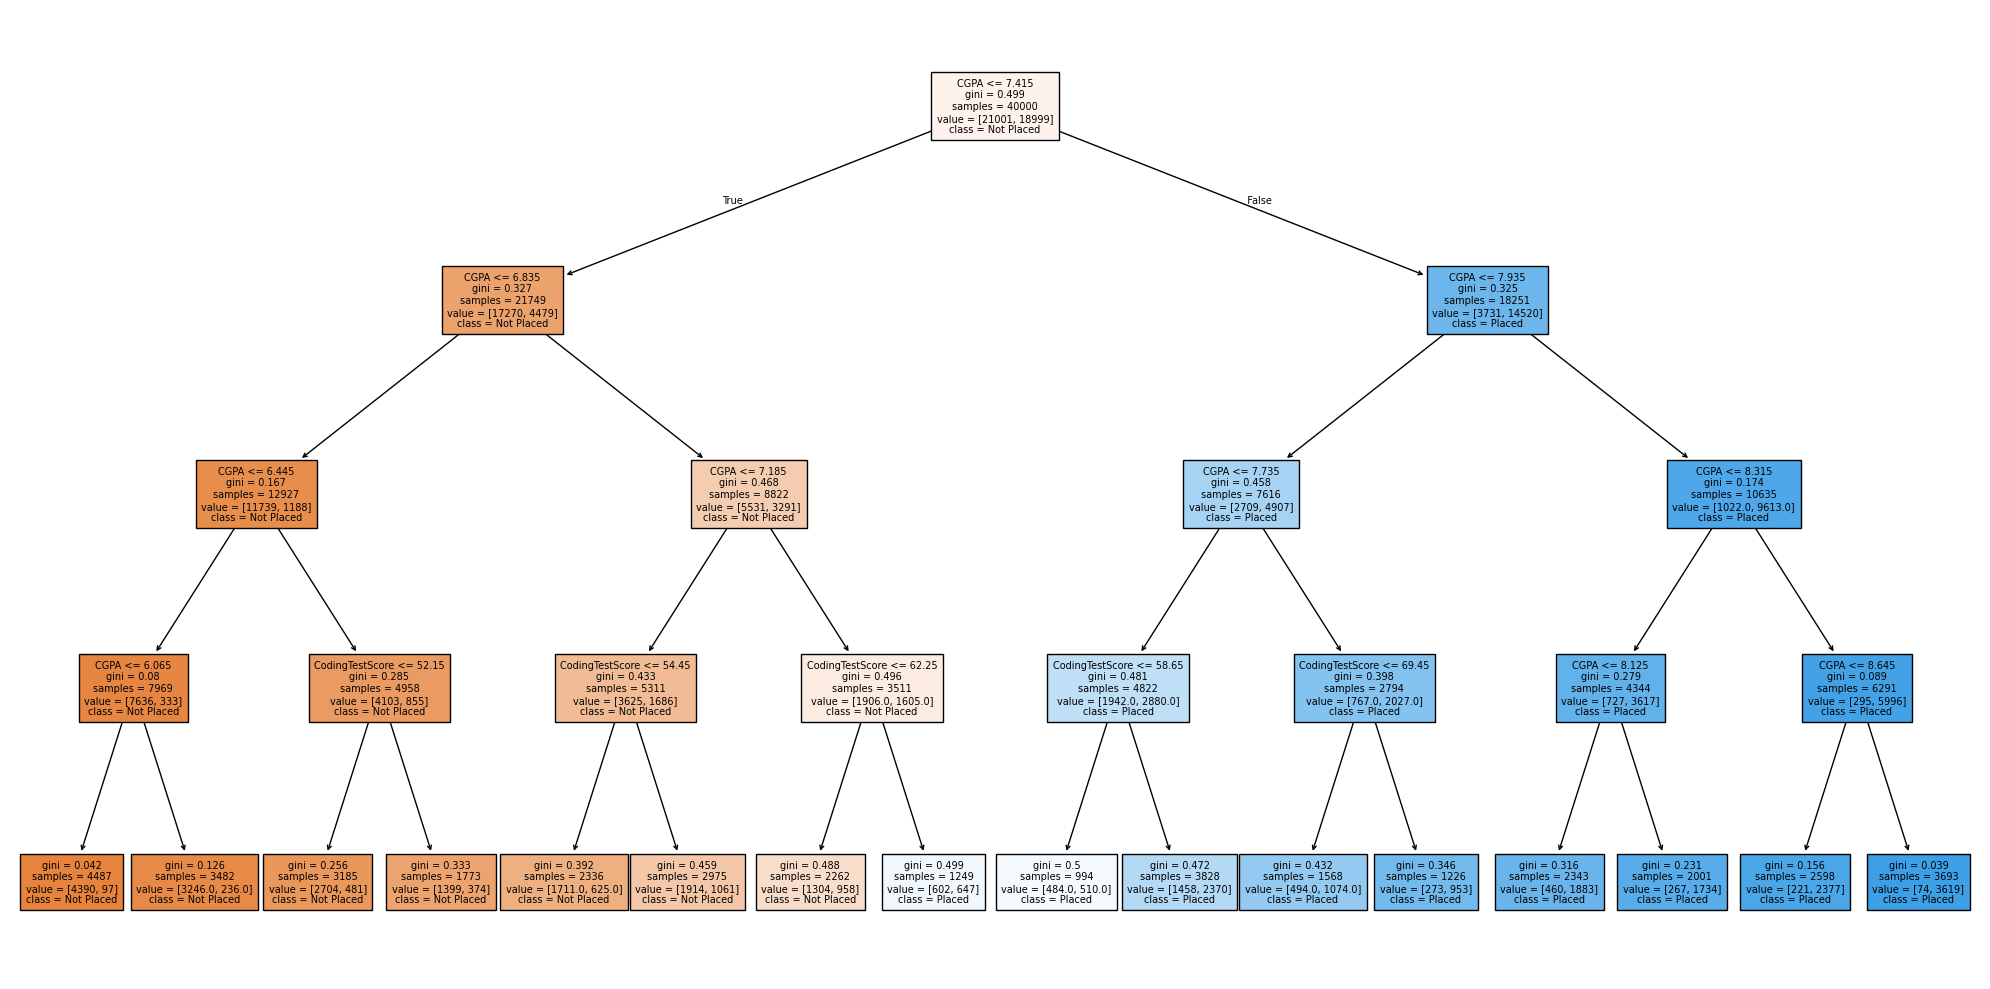


Saved tree image as placement_decision_tree.png


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv('/content/placement_predict_50k_adjusted.csv')

print("Dataset:")
print(df.head())

# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================

if 'IsAnomaly' in df.columns:
    df = df.drop(columns=['IsAnomaly'])

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# ============================================================
# 3. ENCODE CATEGORICAL COLUMNS
# ============================================================

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# 6. CREATE DECISION TREE
# ============================================================

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 7. PREDICTION
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# 8. EVALUATION
# ============================================================

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Placed', 'Placed']
))

# ============================================================
# 9. DISPLAY DECISION TREE
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=7
)

plt.tight_layout()

plt.savefig(
    'placement_decision_tree.png',
    dpi=150
)

plt.show()

print("\nSaved tree image as placement_decision_tree.png")